In [421]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [422]:
df = pd.read_csv('laptops_Price.csv')

In [423]:
df.head()

,Name,Price,Review,Description
0,Asus VivoBook...,$295.99,14,"Asus VivoBook X441NA-GA190 Chocolate Black, 14..."
1,Prestigio Smar...,$299.00,8,"Prestigio SmartBook 133S Dark Grey, 13.3"" FHD ..."
2,Prestigio Smar...,$299.00,12,"Prestigio SmartBook 133S Gold, 13.3"" FHD IPS, ..."
3,Aspire E1-510,$306.99,2,"15.6"", Pentium N3520 2.16GHz, 4GB, 500GB, Linux"
4,Lenovo V110-15...,$321.94,5,"Lenovo V110-15IAP, 15.6"" HD, Celeron N3350 1.1..."


In [424]:
#Data Cleaning
df["Price"] = df["Price"].str.replace("$", "").str.replace(",", "").astype(float)

In [425]:
#For "Brand"
df["Brand"] = df["Name"].str.split().str[0]  # "Lenovo V110..." → "Lenovo"
#le = LabelEncoder()
#df["Brand_enc"] = le.fit_transform(df["Brand"])

In [426]:
#Feature Extraction

#Storage
df['storage'] = df['Description'].str.extract(
    r'((?:64|128|256|500|512|1000|750|180|240|1|32)\s?(?:GB|TB)(?:\s?(?:SSD|HDD|eMMC|Flash Storage))?)'
)
df['storage'] = df['storage'].str.extract(r'(\d+)').astype(float)

#RAM
df['ram'] = df['Description'].str.extract(
    r'(\d+\s?GB)|8GB|6GB|4GB(?:\s?RAM)?'
)
df['ram'] = df['ram'].str.extract(r'(\d+)').astype(float)

#os
df['os'] = df['Description'].str.extract(
    r'(Windows\s?\d+|Windows|Win\d+\s?Pro\s?\d*bit|Mac OS|macOS|Ubuntu|DOS|Linux|Chrome OS|No OS|Endless OS)'
)
df['os'] = df['os'].str.extract(r'(\d+)').astype(float)

#Screensize
df['screen_size'] = df['Description'].str.extract(
    r'(\d{2}\.?\d*)["\s]?(?:inch|")'
)
df['screen_size'] = df['screen_size'].str.extract(r'(\d+)').astype(float)

#cpu
df['cpu'] = df['Description'].str.extract(
    r'(Core i[3579][-\w]*|i[3579][-\w]*|Ryzen \d[\s\w-]*|Celeron[\s\w-]*|Pentium[\s\w-]*|AMD A\d[\w-]*|AMD E\d[\w-]*|Xeon[\s\w-]*|Atom[\s\w-]*|M1|M2)'
)
df['cpu'] = df['cpu'].str.extract(r'(\d+)').astype(float)

In [427]:
df.head()

,Name,Price,Review,Description,Brand,storage,ram,os,screen_size,cpu
0,Asus VivoBook...,295.99,14,"Asus VivoBook X441NA-GA190 Chocolate Black, 14...",Asus,128.0,4.0,NaN,14.0,3450.0
1,Prestigio Smar...,299.00,8,"Prestigio SmartBook 133S Dark Grey, 13.3"" FHD ...",Prestigio,32.0,4.0,10.0,13.0,3350.0
2,Prestigio Smar...,299.00,12,"Prestigio SmartBook 133S Gold, 13.3"" FHD IPS, ...",Prestigio,32.0,4.0,10.0,13.0,3350.0
3,Aspire E1-510,306.99,2,"15.6"", Pentium N3520 2.16GHz, 4GB, 500GB, Linux",Aspire,500.0,4.0,NaN,15.0,3520.0
4,Lenovo V110-15...,321.94,5,"Lenovo V110-15IAP, 15.6"" HD, Celeron N3350 1.1...",Lenovo,128.0,4.0,10.0,15.0,3350.0


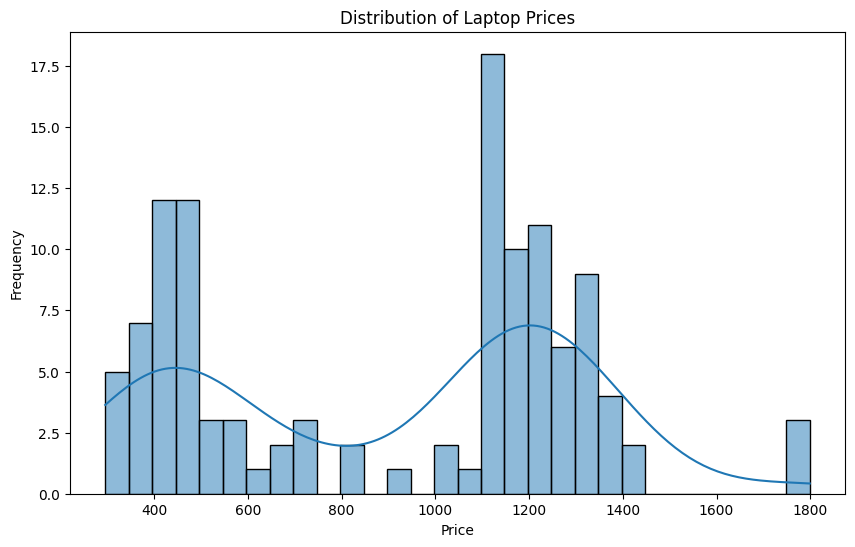

In [428]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Price"], bins=30, kde=True)
plt.title("Distribution of Laptop Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

Text(0, 0.5, 'Count')

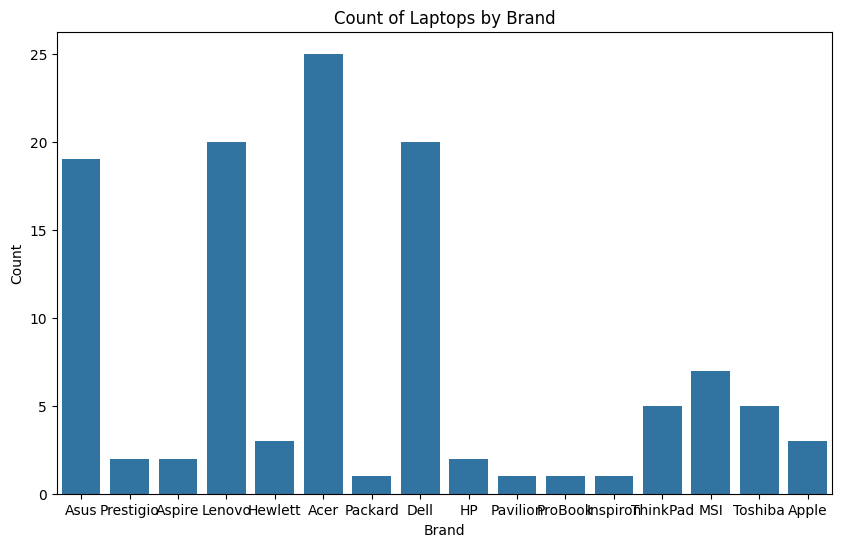

In [429]:
plt.figure(figsize=(10, 6))
sns.countplot(x="Brand", data=df)
plt.title("Count of Laptops by Brand")
plt.xlabel("Brand")
plt.ylabel("Count")

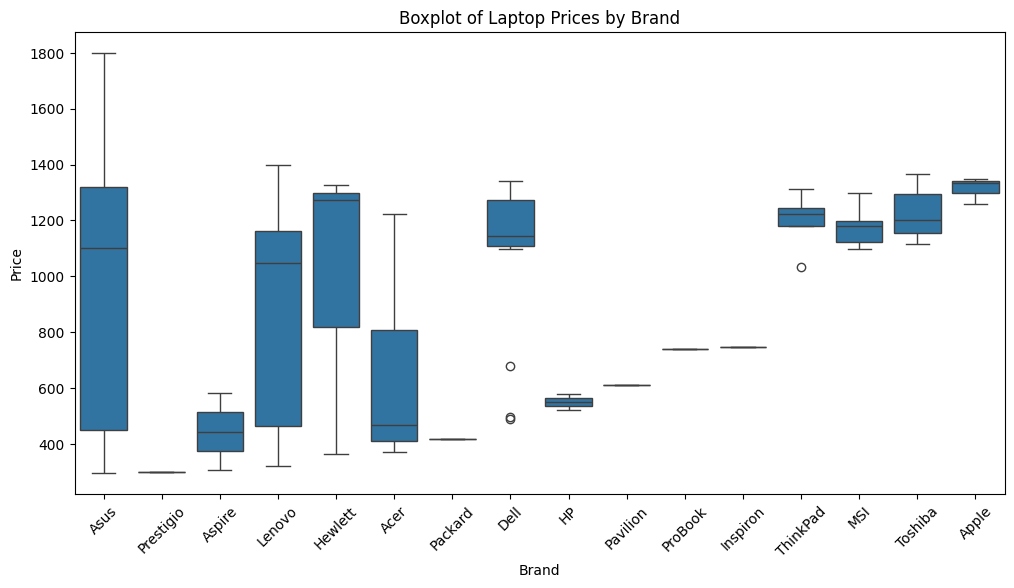

In [430]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="Brand", y="Price", data=df)
plt.title("Boxplot of Laptop Prices by Brand")
plt.xlabel("Brand")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

In [431]:
import warnings
warnings.filterwarnings("ignore")

In [432]:
df["os"].fillna("MacOS", inplace=True)
df['os'] = df['os'].str.extract(r'(\d+)').astype(float)

In [433]:
df.isnull().sum()

Name             0
Price            0
Review           0
Description      0
Brand            0
storage          0
ram              0
os             117
screen_size      0
cpu              1
dtype: int64

In [434]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Brand_enc"] = le.fit_transform(df["Brand"])

In [435]:
features = ["Brand_enc", "storage", "ram", "os", "screen_size", "cpu", "Review"]
X = df[features].fillna(0)
y = df["Price"]

In [436]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [437]:
models = {
    "Linear Regression"  : LinearRegression(),
    "Random Forest"      : RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting"  : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)   # training
    y_preds = model.predict(X_test) # testing

In [438]:
mae  = mean_absolute_error(y_test, y_preds)
rmse = np.sqrt(mean_squared_error(y_test, y_preds))
r2   = r2_score(y_test, y_preds)
cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")

In [450]:
mae 

117.34099434957007

In [449]:
r2

0.8362683201531246

In [452]:
cv_scores

array([-25.52558311,  -4.2809658 ,  -6.38044364, -35.60772163,
        -1.87355553])

In [451]:
rmse

np.float64(173.59185188959114)

In [443]:
importances = rf_model.feature_importances_
fi_df = pd.DataFrame({"Feature": features, "Importance": importances})
fi_df = fi_df.sort_values("Importance", ascending=False)

Text(0.5, 0, 'Feature')

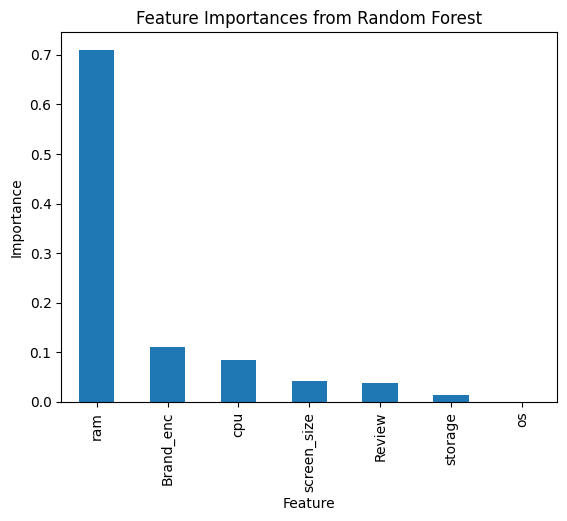

In [444]:
fi_df.plot(kind="bar", x="Feature", y="Importance", legend=False)
plt.title("Feature Importances from Random Forest")
plt.ylabel("Importance")
plt.xlabel("Feature")

In [454]:
#FOR TESTING PURPOSES ONLY

def predict_laptop_price(ram, storage,screen_inch,
                          os, cpu,
                          brand_name="Lenovo", review=5):
    if brand_name in le.classes_:
        brand_enc = le.transform([brand_name])[0]
    else:
        brand_enc = le.transform([le.classes_[0]])[0]  # fallback

    input_data = pd.DataFrame([{...}])
    return round(rf_model.predict(input_data)[0], 2)

In [ ]:
round(predict_laptop_price(ram=16, storage=512, screen_inch=15.6, os="MacOS", cpu=7, brand_name="Apple", review=4), 2)

TypeError: predict_laptop_price() missing 1 required positional argument: 'cpu'

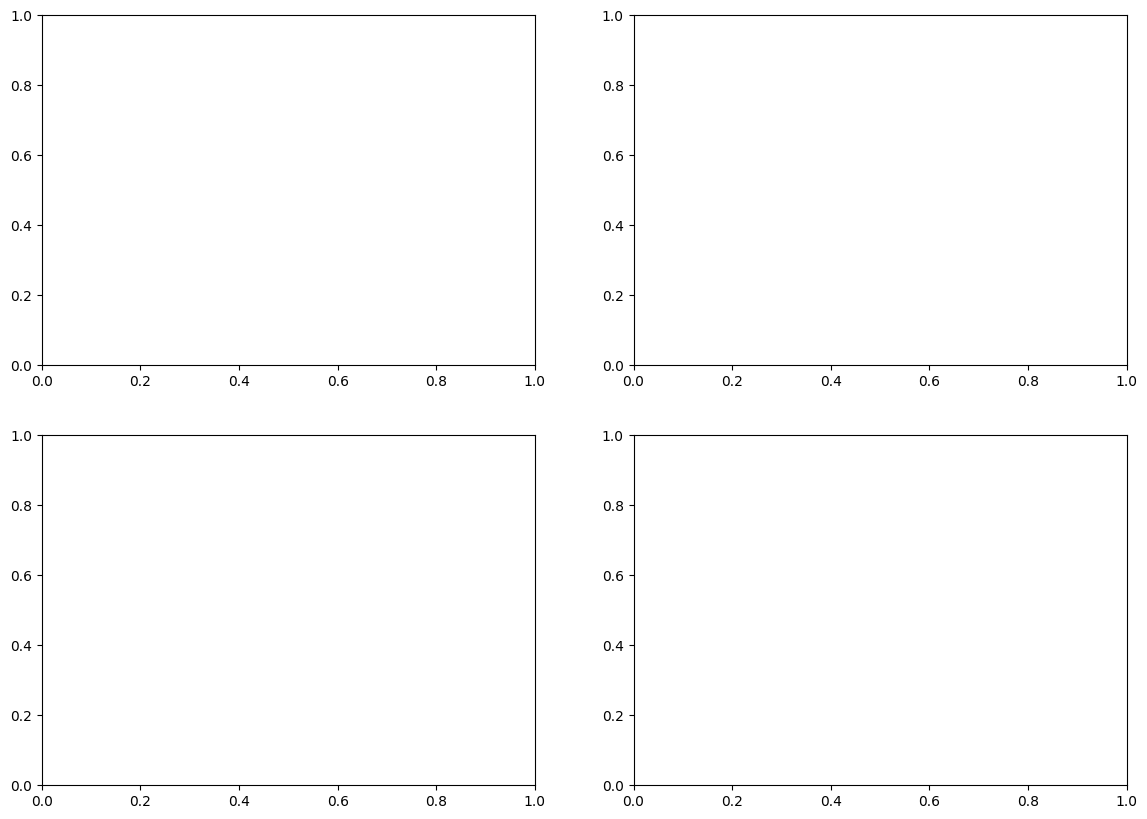

In [442]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))